In [2]:
import torch
print(torch.__version__)          
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))  

2.9.0+cu128
True
Tesla T4


In [3]:
import pandas as pd
from datasets import load_dataset

In [4]:
train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df = val_data.to_pandas()
test_df = test_data.to_pandas()

print("Sample data (first 5 rows):")
print(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

eng/test-00000-of-00001.parquet:   0%|          | 0.00/182k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2763 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/115 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2765 [00:00<?, ? examples/s]

Sample data (first 5 rows):
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  


In [5]:
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
LEVELS = [1, 2, 3] 
LABELS = [f"{e}_{l}" for e in EMOTIONS for l in LEVELS]

def convert_single_step_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    # Emotions used in the study
    emotions = ["anger", "fear", "joy", "sadness", "surprise"]

    # Create binary one-hot columns for intensities 1..3

    for e in emotions:
        df[f"{e}_1"] = (df[e] == 1).astype(int)
        df[f"{e}_2"] = (df[e] == 2).astype(int)
        df[f"{e}_3"] = (df[e] == 3).astype(int)

    return df

train_single = convert_single_step_labels(train_df)
val_single   = convert_single_step_labels(val_df)
test_single  = convert_single_step_labels(test_df) 

print(train_single.head())

                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  fear  joy  sadness  surprise  anger_1  anger_2  anger_3  ...  \
0      0     1    0        0         1        0        0        0  ...   
1      0     2    0        0         0        0        0        0  ...   
2      0     1    0        3         0        0        0        0  ...   
3      0     0    0        0         0        0        0        0  ...   
4      0     3    0        1         2        0        0        0  ...   

   fear_3  joy_1  joy_2  joy_3  sadness_1  sadness_2  sadness_3  sur

In [6]:

def compute_distribution(df, labels):
    return df[labels].sum()

train_counts = compute_distribution(train_single, LABELS)
val_counts   = compute_distribution(val_single, LABELS)
test_counts  = compute_distribution(test_single, LABELS)

distribution_df = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

distribution_df["Total"] = (
    distribution_df["Train"]
    + distribution_df["Validation"]
    + distribution_df["Test"]
)

# Sort by total frequency (nice for plots)


print(distribution_df)

            Train  Validation  Test  Total
anger_1       207           6   188    401
anger_2        88           9    97    194
anger_3        38           1    37     76
fear_1        856          36   832   1724
fear_2        546          19   486   1051
fear_3        208           7   225    440
joy_1         449          20   438    907
joy_2         161          10   176    347
joy_3          64           1    56    121
sadness_1     505          21   524   1050
sadness_2     246           9   224    479
sadness_3     124           4   132    260
surprise_1    588          19   553   1160
surprise_2    215          12   209    436
surprise_3     36           0    37     73


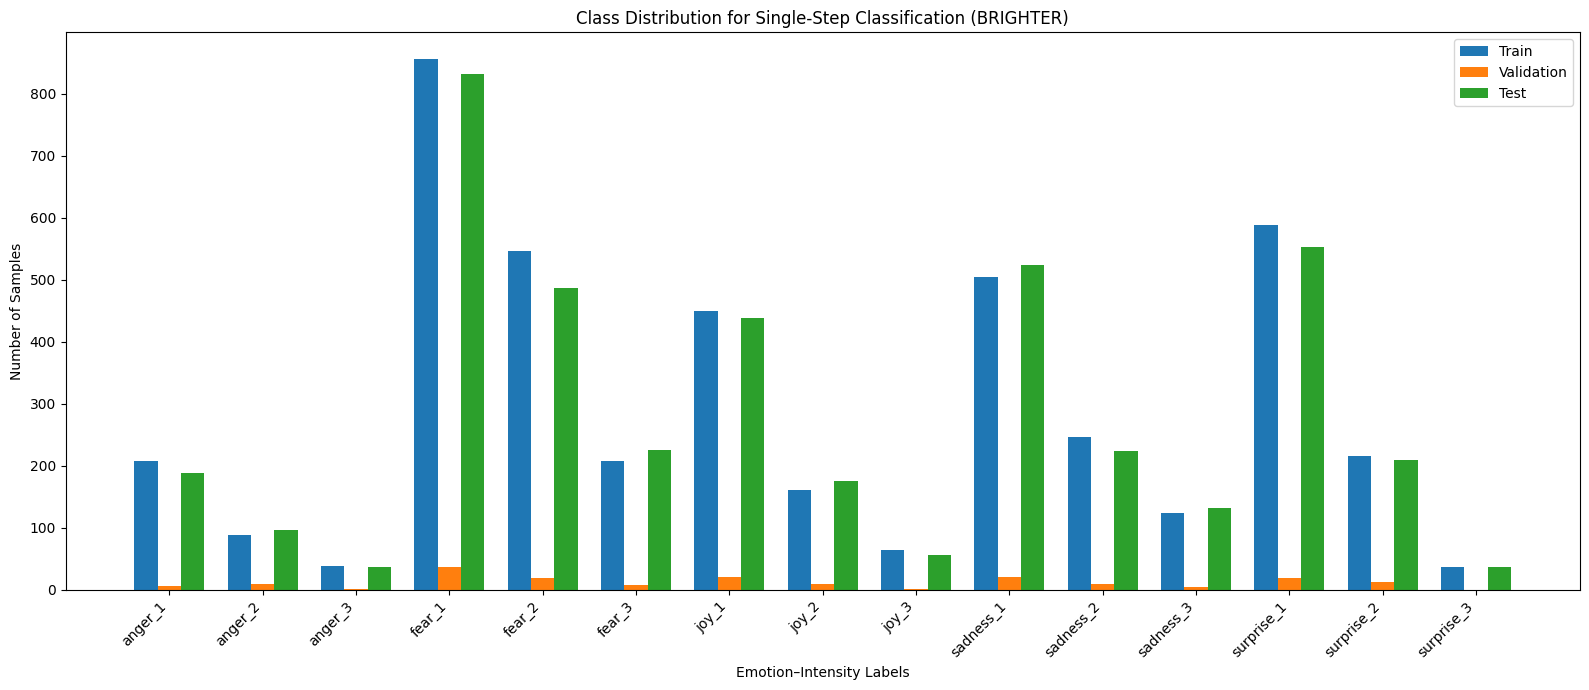

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(distribution_df.index))
width = 0.25

plt.figure(figsize=(16, 7))

plt.bar(x - width, distribution_df["Train"], width, label="Train")
plt.bar(x, distribution_df["Validation"], width, label="Validation")
plt.bar(x + width, distribution_df["Test"], width, label="Test")

plt.xticks(x, distribution_df.index, rotation=45, ha="right")
plt.ylabel("Number of Samples")
plt.xlabel("Emotion–Intensity Labels")
plt.title("Class Distribution for Single-Step Classification (BRIGHTER)")
plt.legend()
plt.tight_layout()
plt.show()

Current sizes: {'train': 2763, 'val': 115, 'test': 2765}
Target sizes : {'train': 3950, 'val': 1129, 'test': 564}
New sizes: {'train': 2763, 'val': 2316, 'test': 564}
New ratios: {'train': 0.48963317384370014, 'val': 0.4104199893673578, 'test': 0.09994683678894205}


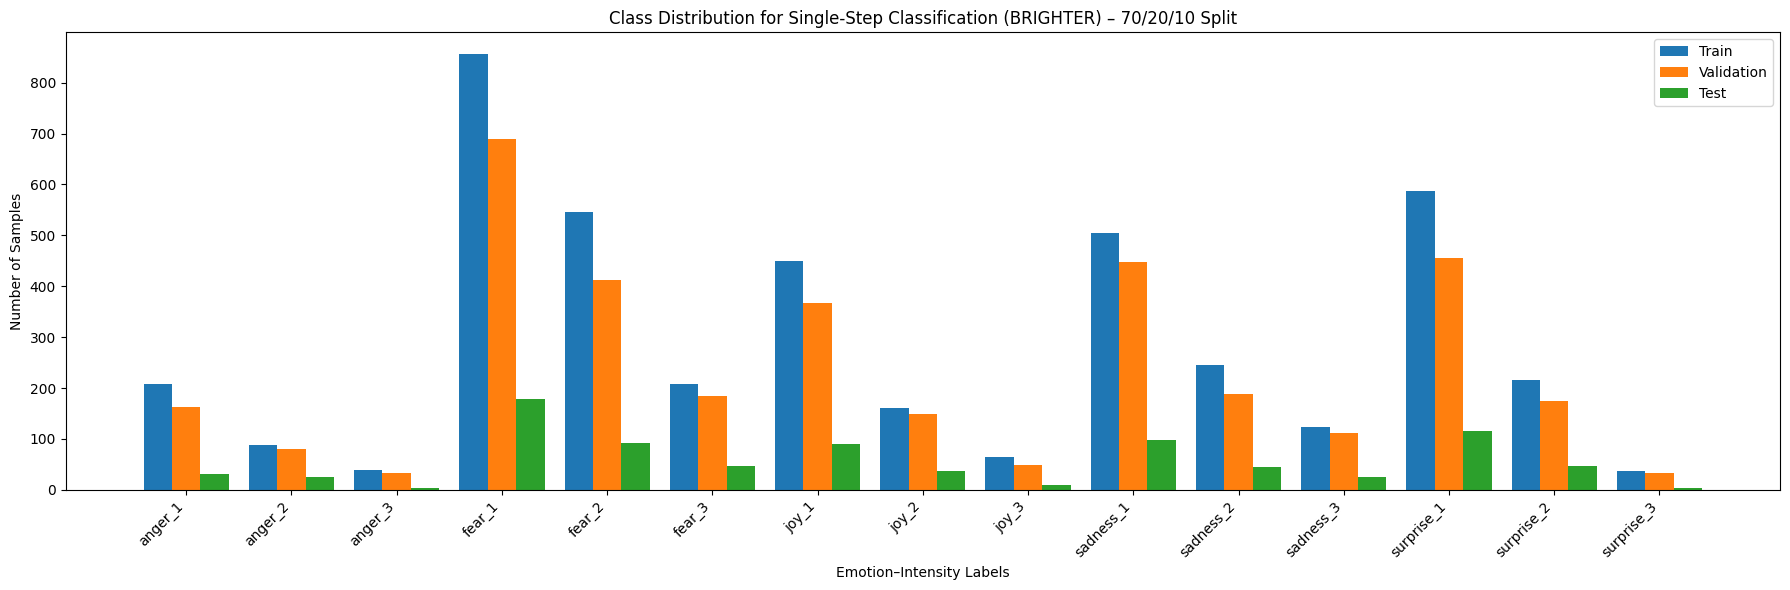

In [9]:
SEED = 42

def rebalance_val_test_70_20_10(train_df, val_df, test_df, seed=42):
    n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
    n_total = n_train + n_val + n_test

    target_train = int(round(0.70 * n_total))
    target_val   = int(round(0.20 * n_total))
    target_test  = n_total - target_train - target_val

    print("Current sizes:", {"train": n_train, "val": n_val, "test": n_test})
    print("Target sizes :", {"train": target_train, "val": target_val, "test": target_test})

    # Keep train fixed; redistribute only (val+test)
    combined = pd.concat([val_df, test_df], ignore_index=True)

    rng = np.random.default_rng(seed)
    combined = combined.iloc[rng.permutation(len(combined))].reset_index(drop=True)

    combined_size = len(combined)
    new_test_size = target_test
    if new_test_size < 0 or new_test_size > combined_size:
        raise ValueError("Target test size is not feasible. Check current split sizes.")

    new_val_size = combined_size - new_test_size

    new_val_df  = combined.iloc[:new_val_size].reset_index(drop=True)
    new_test_df = combined.iloc[new_val_size:].reset_index(drop=True)

    print("New sizes:", {"train": len(train_df), "val": len(new_val_df), "test": len(new_test_df)})
    print("New ratios:", {
        "train": len(train_df)/n_total,
        "val": len(new_val_df)/n_total,
        "test": len(new_test_df)/n_total
    })

    return train_df, new_val_df, new_test_df

train_70, val_20, test_10 = rebalance_val_test_70_20_10(train_single, val_single, test_single, seed=SEED)

# ----------------------------
# 3) Plot class distribution (Train/Val/Test together) for the 15 labels
# ----------------------------
def plot_class_distribution(train_df, val_df, test_df, labels, title):
    train_counts = train_df[labels].sum()
    val_counts   = val_df[labels].sum()
    test_counts  = test_df[labels].sum()

    # Sort by total for readability
    total = (train_counts + val_counts + test_counts)
    sorted_labels = total.index.tolist()

    train_counts = train_counts[sorted_labels]
    val_counts   = val_counts[sorted_labels]
    test_counts  = test_counts[sorted_labels]

    x = np.arange(len(sorted_labels))
    width = 0.27

    plt.figure(figsize=(18, 6))
    plt.bar(x - width, train_counts.values, width, label="Train")
    plt.bar(x,         val_counts.values,   width, label="Validation")
    plt.bar(x + width, test_counts.values,  width, label="Test")

    plt.xticks(x, sorted_labels, rotation=45, ha="right")
    plt.xlabel("Emotion–Intensity Labels")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_class_distribution(
    train_70, val_20, test_10,
    LABELS,
    "Class Distribution for Single-Step Classification (BRIGHTER) – 70/20/10 Split"
)